## 1. Import data 

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
t_eval = np.load('data/t_eval.npy', allow_pickle = True)
returns = pd.read_csv('data/returns.csv', index_col = 0, parse_dates = True)

print(len(t_eval))
returns


83


,AAPL,ABBV,AEP,AMT,AMZN,APD,AVGO,BAC,BLK,CAT,...,SLB,SO,SPG,T,TSLA,UNH,UNP,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2013-02-01,-0.025611,0.006249,0.043118,0.018862,-0.004644,-0.012546,-0.044299,-0.007083,0.014579,-0.063137,...,0.001279,0.017481,-0.001216,0.031686,-0.074129,-0.032398,0.047276,0.007152,0.011796,0.001690
2013-03-01,0.002850,0.099439,0.038571,-0.008801,0.008365,0.017102,0.053786,0.081206,0.076000,-0.060239,...,-0.038764,0.041559,-0.001890,0.021488,0.084208,0.071856,0.037926,0.053017,0.062073,0.006234
2013-04-01,0.000271,0.130748,0.055981,0.091278,-0.048751,-0.001839,-0.116809,0.010617,0.036765,-0.020398,...,-0.006161,0.027537,0.116044,0.036564,0.354112,0.046449,0.038232,0.026412,0.037894,-0.012507
2013-05-01,0.022172,-0.075763,-0.105860,-0.076042,0.058869,0.082199,0.165970,0.104060,0.046554,0.013257,...,-0.018988,-0.083412,-0.061105,-0.068212,0.593717,0.044067,0.048412,0.073319,-0.031780,0.023388
2013-06-01,-0.125896,-0.032134,-0.022959,-0.058244,0.031051,-0.023130,-0.003466,-0.059601,-0.077123,-0.039342,...,-0.014642,0.005225,-0.052546,0.011650,0.093672,0.048897,-0.002201,0.017600,-0.004688,-0.001327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.031841,0.057611,0.030791,0.016470,-0.046413,0.055293,0.013231,0.010856,0.028467,0.028195,...,-0.093262,0.042177,0.086778,0.033209,-0.080549,0.024076,0.042541,-0.007159,0.120759,0.002523
2024-09-01,0.017316,0.005942,0.022872,0.037234,0.042931,0.065546,0.061036,-0.020110,0.057442,0.093803,...,-0.040960,0.042820,0.022470,0.100323,0.200441,-0.005857,-0.038248,-0.034450,0.044570,-0.006124
2024-10-01,-0.030902,0.039799,-0.038246,-0.078075,0.000376,0.048022,-0.015953,0.052528,0.032657,-0.035307,...,-0.045850,0.009382,0.000592,0.037007,-0.046071,-0.035124,-0.060242,0.139092,0.014751,-0.003761


## 2. PCA and Covariance Estimation

In [3]:
from sklearn.decomposition import PCA

lookback = 36
window = returns.iloc[-lookback-1:-1]
pca = PCA()
pca.fit(window)
variance_pct = pca.explained_variance_ratio_
cum_var = np.cumsum(variance_pct)
k = np.argmax(cum_var >= 0.8) + 1

Text(0.5, 1.0, 'Cross-Sectional Cumulative Variance')

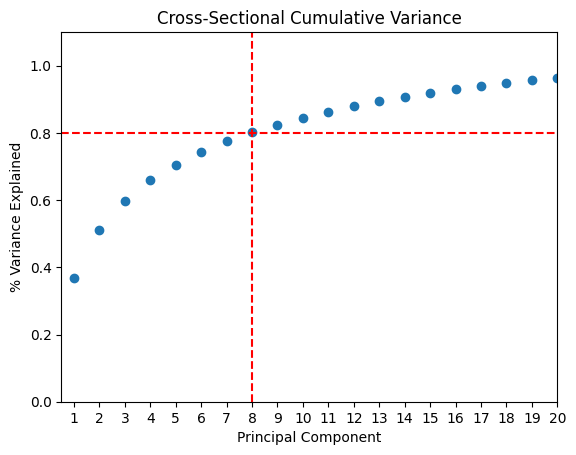

In [4]:

plt.scatter(range(1, 1 + len(cum_var)), cum_var)
plt.axhline(0.8, color = 'r', ls = '--')
plt.axvline(k, color = 'r', ls = '--')
plt.xlim(0.5,20)
plt.ylim(0,1.1)
plt.xticks(np.linspace(1,20,20))
plt.xlabel('Principal Component')
plt.ylabel('% Variance Explained')
plt.title('Cross-Sectional Cumulative Variance')



In [16]:
len(range(lookback, len(returns)))

107

In [17]:
len(returns)

143

In [5]:
lookback = 36
threshold = 0.8
sigma_list = []

for t in range(lookback, len(returns)):
    # Lookback window
    window = returns.iloc[t-lookback:t]
    print(returns.index[t])
    # PCA deconstruction
    pca = PCA()
    pca.fit(window)

    cum_var = np.cumsum(pca.explained_variance_ratio_)
    k = np.argmax(cum_var >= threshold)

    B = pca.components_[:k,:]
    F = np.diag(pca.explained_variance_[:k])

    sigma_pca = B.T @ F @ B

    sample_cov = window.cov().values

    D = np.diag(np.diag(sample_cov - sigma_pca))

    sigma_t = sigma_pca + D

    sigma_list.append(sigma_t)

# Stack along axis 2
sigma = np.stack(sigma_list, axis=2)
sigma.shape


2016-02-01 00:00:00
2016-03-01 00:00:00
2016-04-01 00:00:00
2016-05-01 00:00:00
2016-06-01 00:00:00
2016-07-01 00:00:00
2016-08-01 00:00:00
2016-09-01 00:00:00
2016-10-01 00:00:00
2016-11-01 00:00:00
2016-12-01 00:00:00
2017-01-01 00:00:00
2017-02-01 00:00:00
2017-03-01 00:00:00
2017-04-01 00:00:00
2017-05-01 00:00:00
2017-06-01 00:00:00
2017-07-01 00:00:00
2017-08-01 00:00:00
2017-09-01 00:00:00
2017-10-01 00:00:00
2017-11-01 00:00:00
2017-12-01 00:00:00
2018-01-01 00:00:00
2018-02-01 00:00:00
2018-03-01 00:00:00
2018-04-01 00:00:00
2018-05-01 00:00:00
2018-06-01 00:00:00
2018-07-01 00:00:00
2018-08-01 00:00:00
2018-09-01 00:00:00
2018-10-01 00:00:00
2018-11-01 00:00:00
2018-12-01 00:00:00
2019-01-01 00:00:00
2019-02-01 00:00:00
2019-03-01 00:00:00
2019-04-01 00:00:00
2019-05-01 00:00:00
2019-06-01 00:00:00
2019-07-01 00:00:00
2019-08-01 00:00:00
2019-09-01 00:00:00
2019-10-01 00:00:00
2019-11-01 00:00:00
2019-12-01 00:00:00
2020-01-01 00:00:00
2020-02-01 00:00:00
2020-03-01 00:00:00


(60, 60, 107)

## 3. Risk-Adjusted Alpha Allocation

In [6]:
def standardise(df: pd.DataFrame) -> pd.DataFrame:
    def standardise_row(row):
        mu = row.mean()
        sig = row.std()
        if sig == 0:
            return row - mu
        return (row - mu) / sig

    return df.apply(standardise_row, axis=1)

def normalise(df: pd.DataFrame) -> pd.DataFrame:
    def normalise_row(row):
        tot = row.abs().sum()
        return row / tot

    return df.apply(normalise_row, axis=1)

In [7]:
scores = pd.read_csv('data/factor_scores.csv', index_col = 0, parse_dates = True)
scores_n = normalise(scores)
scores_n

,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.011202,0.006839,0.099165,0.020496,0.016888,0.010876,0.019799,0.010584,0.017250,0.012393,...,-0.009062,-0.001131,0.002420,-0.018092,-0.020579,-0.006280,-0.009337,-0.010537,0.061588,0.013848
2018-02-01,-0.001309,0.002526,0.106169,0.013176,0.011542,0.007346,0.013602,0.003433,0.011799,0.011986,...,-0.004003,-0.000843,0.014153,-0.019403,-0.026316,-0.002490,-0.008057,-0.006278,0.047549,0.012320
2018-03-01,-0.008328,0.010850,0.115390,0.003728,0.000275,0.010581,0.021020,-0.000084,0.009345,0.006558,...,0.000539,-0.004707,0.021443,-0.021863,-0.025092,-0.007081,-0.015126,-0.011121,0.027108,0.005014
2018-04-01,0.000446,0.011742,0.108771,0.002344,-0.000503,0.008455,0.018307,-0.001978,0.007361,0.005018,...,-0.007037,-0.004927,0.010518,-0.023984,-0.029939,-0.008096,-0.019231,-0.009628,0.038722,0.003004
2018-05-01,0.009654,0.006469,0.083234,0.008739,-0.003794,0.003319,0.014428,-0.006432,0.002917,0.000106,...,-0.005157,-0.005054,0.008189,-0.024637,-0.030053,-0.010545,-0.022417,-0.015082,0.041821,0.002369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,-0.003260,0.001287,0.082607,0.042975,0.007767,-0.003049,-0.002730,-0.000790,0.008527,-0.011335,...,0.013297,0.003179,-0.015205,-0.002803,-0.004766,-0.018087,-0.027812,0.025428,0.016384,0.007747
2024-08-01,0.002772,0.002903,0.080230,0.037961,0.022613,-0.015302,-0.010556,-0.009759,0.007520,0.001161,...,0.029068,0.013464,-0.004849,-0.005117,0.013364,-0.020026,-0.019882,0.025752,0.015611,0.014652
2024-09-01,0.009941,0.011947,0.085904,0.046086,0.015045,0.001878,-0.010121,-0.002344,0.005210,-0.004230,...,0.019941,0.002211,-0.012636,-0.010264,0.005183,-0.016766,-0.021711,0.017617,0.011431,0.009921


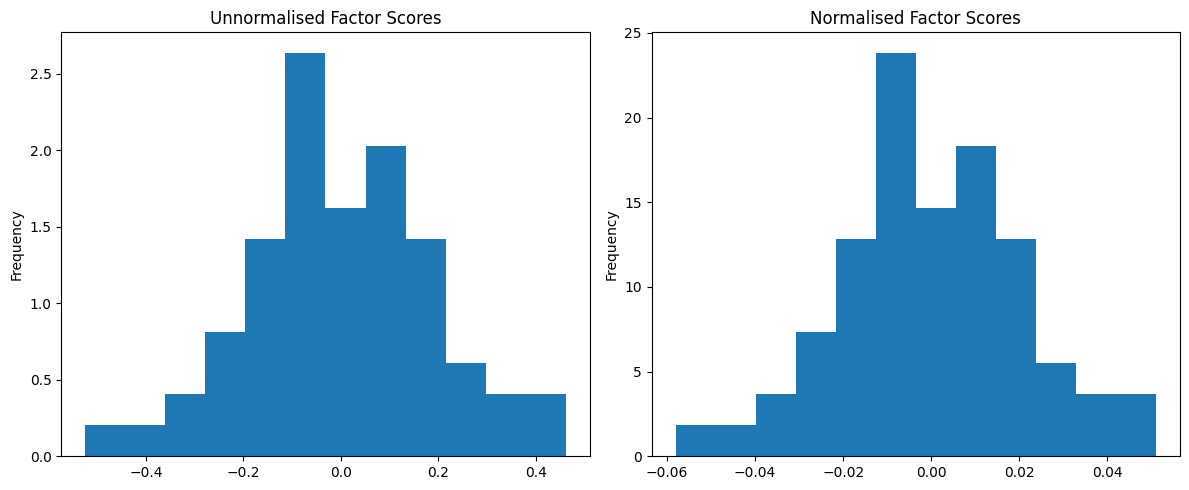

In [8]:
fig, ax = plt.subplots(1, 2, figsize = (12,5))
scores.iloc[60].plot(ax = ax[0], kind = 'hist', bins = 12, density = True)
scores_n.iloc[60].plot(ax = ax[1], kind = 'hist', bins = 12, density = True)
ax[0].set_title('Unnormalised Factor Scores')
ax[1].set_title('Normalised Factor Scores')
plt.tight_layout()

In [9]:
t_eval = scores.index
sigma_t = sigma[:,:,-len(t_eval):]
sigma_t.shape

(60, 60, 83)

In [10]:
weights_t = pd.DataFrame(
    index = t_eval, 
    columns = scores.columns
)
for i,t in enumerate(t_eval):
    mu_t = scores_n.loc[t].values
    sigma_t_i = sigma[:,:,i]

    w = np.linalg.solve(sigma_t_i, mu_t)
    w = w - w.mean() # denorm
    w = w / np.abs(w).sum() # scale exposure

    weights_t.loc[t] = w

print(weights_t.sum(axis = 1))
print(weights_t.abs().sum(axis = 1))


Date
2018-01-01   -0.0
2018-02-01   -0.0
2018-03-01   -0.0
2018-04-01    0.0
2018-05-01    0.0
             ... 
2024-07-01    0.0
2024-08-01    0.0
2024-09-01   -0.0
2024-10-01   -0.0
2024-11-01   -0.0
Length: 83, dtype: object
Date
2018-01-01    1.0
2018-02-01    1.0
2018-03-01    1.0
2018-04-01    1.0
2018-05-01    1.0
             ... 
2024-07-01    1.0
2024-08-01    1.0
2024-09-01    1.0
2024-10-01    1.0
2024-11-01    1.0
Length: 83, dtype: object


In [11]:
# Calculate Risk-adjusted Returns
returns_eval = pd.read_csv('data/returns_eval.csv', index_col = 0, parse_dates = True)

ra_returns = (returns_eval * weights_t).sum(axis = 1)
ra_returns.to_csv('outputs/ra_returns.csv')

## 4. Mean-Variance Optimisation

In [12]:
import cvxpy as cp

In [13]:
assets = scores.columns
n = len(assets)
mvo = {}
lams = np.arange(1,50,1)

for lam in lams:

    weights_mvo = pd.DataFrame(index=t_eval, columns=assets)

    for i, t in enumerate(t_eval):

        mu = scores_n.loc[t].values
        Sigma = sigma_t[:, :, i]

        w_mvo = cp.Variable(n)

        objective = cp.Maximize(
            mu @ w_mvo - 0.5 * lam * cp.quad_form(w_mvo, Sigma)
        )

        constraints = [
            cp.sum(w_mvo) == 0,          # market neutral
            cp.norm1(w_mvo) <= 1         # leverage constraint
        ]

        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.OSQP)

        weights_mvo.loc[t] = w_mvo.value

    #print(weights_mvo.abs().sum(axis = 1))
    #print(weights_mvo.sum(axis = 1))

    mvo[lam] = weights_mvo

mvo.keys()

C:\Users\godwi\AppData\Local\Temp\ipykernel_26516\388548118.py:27: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.OSQP)


dict_keys([np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49)])

In [14]:
mvo_returns = {}
for lam in lams:
    mvo_returns[lam] = (returns_eval * mvo[lam]).sum(axis = 1)

np.save('outputs/mvo_returns_lambda.npy', mvo_returns)

## 5. Plots